<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/02_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Notebook 02 — Decision Tree Model
**Chủ đề 12:** Cây Quyết Định Phân Loại Bệnh Tiểu Đường (Pima Indians)

| Phần | Thành viên phụ trách |
|------|----------------------|
| Setup & Preprocessing | Nguyễn Thị Trâm |
| Train Decision Tree (Baseline) | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Tối ưu với GridSearchCV | Lê Tấn Phú · Nguyễn Thị Trâm |
| Metrics & ROC Curve | Nguyễn Thị Mỹ Quyên · Nguyễn Thị Trâm |
| Trực quan cây & Feature Importance | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Kết luận | Nguyễn Thị Trâm |

> ⚠️ **Lưu ý y tế:** Trong bài toán phân loại bệnh, **Recall** quan trọng hơn Accuracy
> vì bỏ sót người bệnh (False Negative) nguy hiểm hơn báo nhầm (False Positive).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Import thành công")

✅ Import thành công


In [ ]:
!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes

df = pd.read_csv("data/diabetes.csv")

# Làm sạch: thay 0 → NaN cho các cột bất hợp lý về y học
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tỷ lệ dương tính – Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 101 (delta 39), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 526.35 KiB | 1.87 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/content/decision-tree-pima-diabetes
Train: (614, 8)  |  Test: (154, 8)
Tỷ lệ dương tính – Train: 34.85%  |  Test: 35.06%


In [ ]:
# ── Train Decision Tree Baseline ────────────────────────────

pipeline_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  #thay missing = mean
    ("scaler",  StandardScaler()),                  #chuan hoa du lieu
    ("clf",     DecisionTreeClassifier(             #train
                    criterion="gini",
                    random_state=42

                ))
])

pipeline_baseline.fit(X_train, y_train)
print("✅ Đã train Decision Tree Baseline!")
print(f"   Số node của cây  : {pipeline_baseline.named_steps['clf'].tree_.node_count}")
print(f"   Độ sâu tối đa    : {pipeline_baseline.named_steps['clf'].get_depth()}")

✅ Đã train Decision Tree Baseline!
   Số node của cây  : 221
   Độ sâu tối đa    : 14


In [ ]:
# ── Dự đoán & tính metrics ──────────────────────────────────
y_pred_baseline = pipeline_baseline.predict(X_test)

acc_b  = accuracy_score(y_test,  y_pred_baseline)
prec_b = precision_score(y_test, y_pred_baseline)
rec_b  = recall_score(y_test,    y_pred_baseline)
f1_b   = f1_score(y_test,        y_pred_baseline)

print("KẾT QUẢ DECISION TREE BASELINE:")
print(f"   Accuracy  : {acc_b:.4f}  ({acc_b*100:.1f}%)")
print(f"   Precision : {prec_b:.4f}  ({prec_b*100:.1f}%)")
print(f"   Recall    : {rec_b:.4f}  ({rec_b*100:.1f}%)  ← QUAN TRỌNG NHẤT trong y tế!")
print(f"   F1-Score  : {f1_b:.4f}  ({f1_b*100:.1f}%)")
print()
print("Chi tiết Classification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=["Không tiểu đường", "Tiểu đường"]))

KẾT QUẢ DECISION TREE BASELINE:
   Accuracy  : 0.6818  (68.2%)
   Precision : 0.5532  (55.3%)
   Recall    : 0.4815  (48.1%)  ← QUAN TRỌNG NHẤT trong y tế!
   F1-Score  : 0.5149  (51.5%)

Chi tiết Classification Report:
                  precision    recall  f1-score   support

Không tiểu đường       0.74      0.79      0.76       100
      Tiểu đường       0.55      0.48      0.51        54

        accuracy                           0.68       154
       macro avg       0.65      0.64      0.64       154
    weighted avg       0.67      0.68      0.68       154



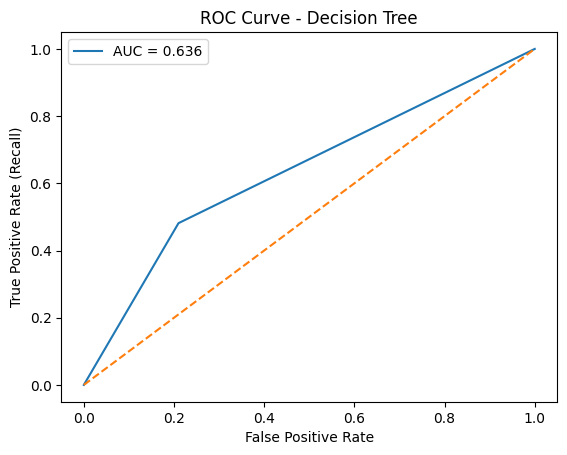

In [ ]:
y_proba = pipeline_baseline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--') #duong de so sanh

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Decision Tree")

plt.legend()
plt.show()

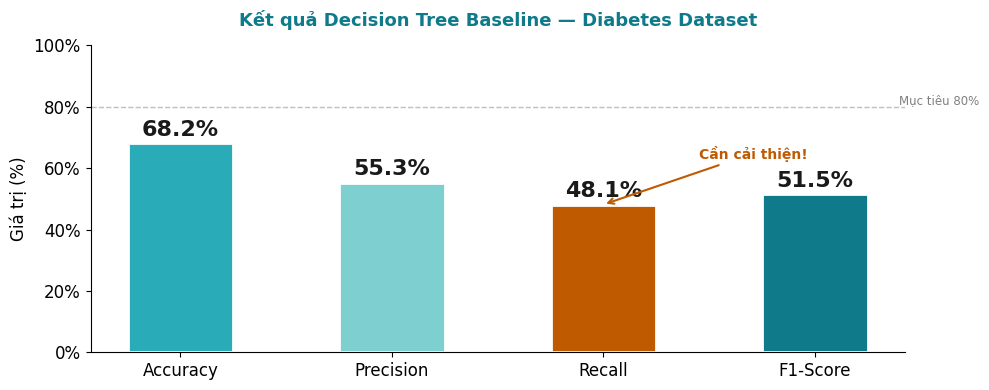

In [ ]:
# ── Biểu đồ kết quả ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

metrics_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_vals   = [acc_b, prec_b, rec_b, f1_b]
metrics_colors = ["#2AABB8", "#7ECFCF", "#C05A00", "#0E7A8A"]

bars = ax.bar(metrics_names, [v*100 for v in metrics_vals],
              color=metrics_colors, width=0.5, edgecolor="white", linewidth=2)

for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val*100:.1f}%", ha="center", va="bottom",
            fontsize=16, fontweight="bold", color="#1A1A1A")

ax.annotate("Cần cải thiện!",
            xy=(2, rec_b*100), xytext=(2.45, rec_b*100 + 15),
            fontsize=10, color="#C05A00", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#C05A00", lw=1.5))

ax.set_ylim(0, 100)
ax.set_ylabel("Giá trị (%)", fontsize=12)
ax.set_title("Kết quả Decision Tree Baseline — Diabetes Dataset",
             fontsize=13, fontweight="bold", color="#0E7A8A", pad=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.axhline(y=80, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(3.4, 81, "Mục tiêu 80%", fontsize=8.5, color="gray")

plt.tight_layout()
plt.show()

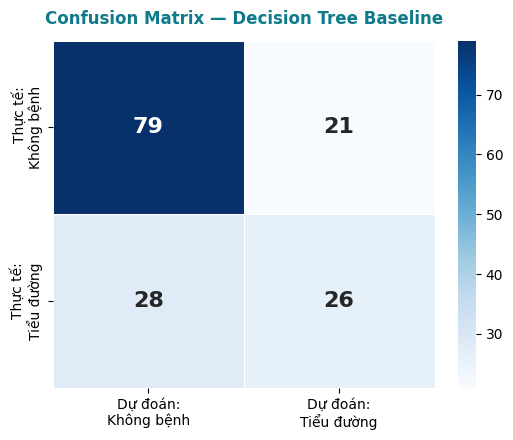

TN = 79  → Đoán đúng người KHÔNG bệnh ✅
FP = 21  → Báo nhầm người lành là bệnh
FN = 28  → BỎ SÓT người bệnh thật ⚠ nguy hiểm nhất!
TP = 26  → Phát hiện đúng người bệnh ✅


In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán:\nKhông bệnh", "Dự đoán:\nTiểu đường"],
            yticklabels=["Thực tế:\nKhông bệnh", "Thực tế:\nTiểu đường"],
            linewidths=0.5, linecolor="white", ax=ax,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_title("Confusion Matrix — Decision Tree Baseline",
             fontsize=12, fontweight="bold", color="#0E7A8A", pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}  → Đoán đúng người KHÔNG bệnh ✅")
print(f"FP = {fp}  → Báo nhầm người lành là bệnh")
print(f"FN = {fn}  → BỎ SÓT người bệnh thật ⚠ nguy hiểm nhất!")
print(f"TP = {tp}  → Phát hiện đúng người bệnh ✅")

In [ ]:
# Tối ưu + GridSearch

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# khởi tạo mô hình
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # điền NaN bằng trung vị
    ("scaler",  StandardScaler()),                   # chuẩn hóa về mean=0, std=1
    ("clf",     DecisionTreeClassifier(
                  random_state=42,
                  class_weight='balanced'
                  ))
])

# lưới bộ tham số được chọn để huấn luyện
param_grid = {
    "clf__max_depth":        [3, 4, 5, 6, 7, None],
    "clf__min_samples_split": [2, 5, 10, 20],
}

# chia nhỏ tập train thành nhiều fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# công cụ tìm bộ siêu tham số tốt nhất
grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = "recall",
    n_jobs     = -1,
    verbose    = 1,
    refit      = True        # tự động re-train trên toàn bộ train set với best params
)

# huấn luyện lại
grid_search.fit(X_train, y_train)

print("\nKẾT QUẢ TỐI ƯU HÓA GRIDSEARCH:")
print(f"Bộ tham số tốt nhất: {grid_search.best_params_}")
print(f"Điểm Recall cao nhất (Cross-Validation): {grid_search.best_score_:.4f}\n")

# Lấy mô hình xuất sắc nhất (đã được refit tự động)
best_model = grid_search.best_estimator_

# Cho mô hình thực hiện trên tập Test (Dữ liệu chưa từng thấy)
y_pred_optimized = best_model.predict(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

KẾT QUẢ TỐI ƯU HÓA GRIDSEARCH:
Bộ tham số tốt nhất: {'clf__max_depth': 3, 'clf__min_samples_split': 2}
Điểm Recall cao nhất (Cross-Validation): 0.8369



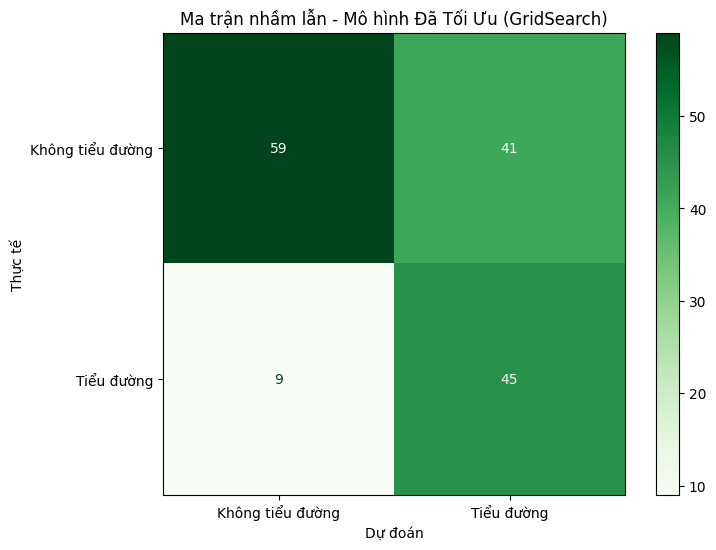

TN = 59  → Đoán đúng người KHÔNG bệnh
FP = 41  → Báo nhầm người lành là bệnh
FN = 9  → BỎ SÓT người bệnh thật đã giảm đáng kể!
TP = 45  → Phát hiện đúng người bệnh


In [ ]:
# ma trận nhầm lẫn của mô hình gridsearch

from sklearn.metrics import ConfusionMatrixDisplay

# Vẽ Confusion Matrix của mô hình đã tối ưu (đổi màu xanh lá để phân biệt với Baseline)
fig, ax = plt.subplots(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=["Không tiểu đường", "Tiểu đường"])
disp.plot(cmap='Greens', values_format='d', ax=ax)
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Thực tế")
plt.title("Ma trận nhầm lẫn - Mô hình Đã Tối Ưu (GridSearch)")
plt.show()

tn, fp, fn, tp = cm_opt.ravel()
print(f"TN = {tn}  → Đoán đúng người KHÔNG bệnh")
print(f"FP = {fp}  → Báo nhầm người lành là bệnh")
print(f"FN = {fn}  → BỎ SÓT người bệnh thật đã giảm đáng kể!")
print(f"TP = {tp}  → Phát hiện đúng người bệnh")

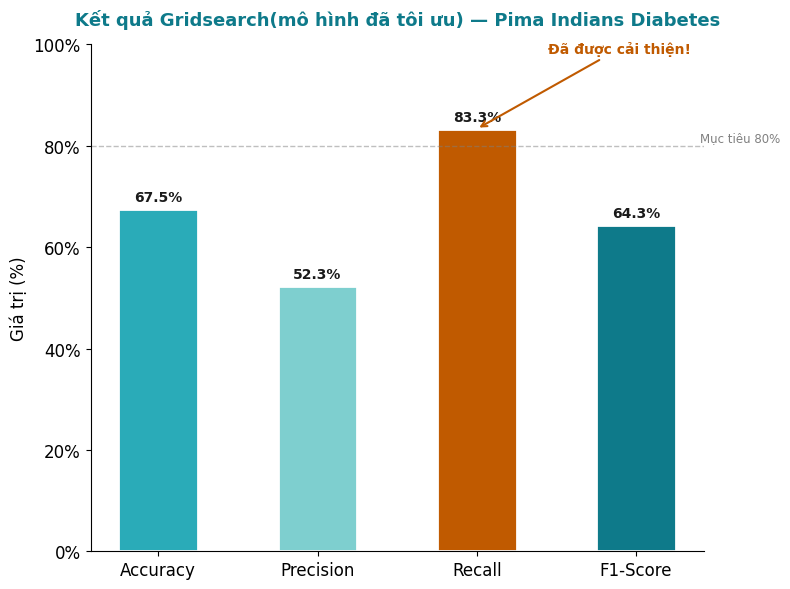

In [ ]:
# biếu đồ cột các tiêu chí của mô hình gridsearch

# khai báo các biến tiêu chí đánh giá
acc_p  = accuracy_score(y_test,  y_pred_optimized)
prec_p = precision_score(y_test, y_pred_optimized)
rec_p  = recall_score(y_test,    y_pred_optimized)
f1_p   = f1_score(y_test,        y_pred_optimized)

# biểu đồ cột các tiêu chí
fig, ax = plt.subplots(figsize=(8, 6))

metrics_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_vals   = [acc_p, prec_p, rec_p, f1_p]
metrics_colors = ["#2AABB8", "#7ECFCF", "#C05A00", "#0E7A8A"]

bars = ax.bar(metrics_names, [v*100 for v in metrics_vals],
              color=metrics_colors, width=0.5, edgecolor="white", linewidth=2)

for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val*100:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1A1A1A")

ax.annotate("Đã được cải thiện!",
            xy=(2, rec_p*100), xytext=(2.45, rec_p*100 + 15),
            fontsize=10, color="#C05A00", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#C05A00", lw=1.5))

ax.set_ylim(0, 100)
ax.set_ylabel("Giá trị (%)", fontsize=12)
ax.set_title("Kết quả Gridsearch(mô hình đã tôi ưu) — Pima Indians Diabetes",
             fontsize=13, fontweight="bold", color="#0E7A8A", pad=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.axhline(y=80, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(3.4, 81, "Mục tiêu 80%", fontsize=8.5, color="gray")

plt.tight_layout()
plt.show()

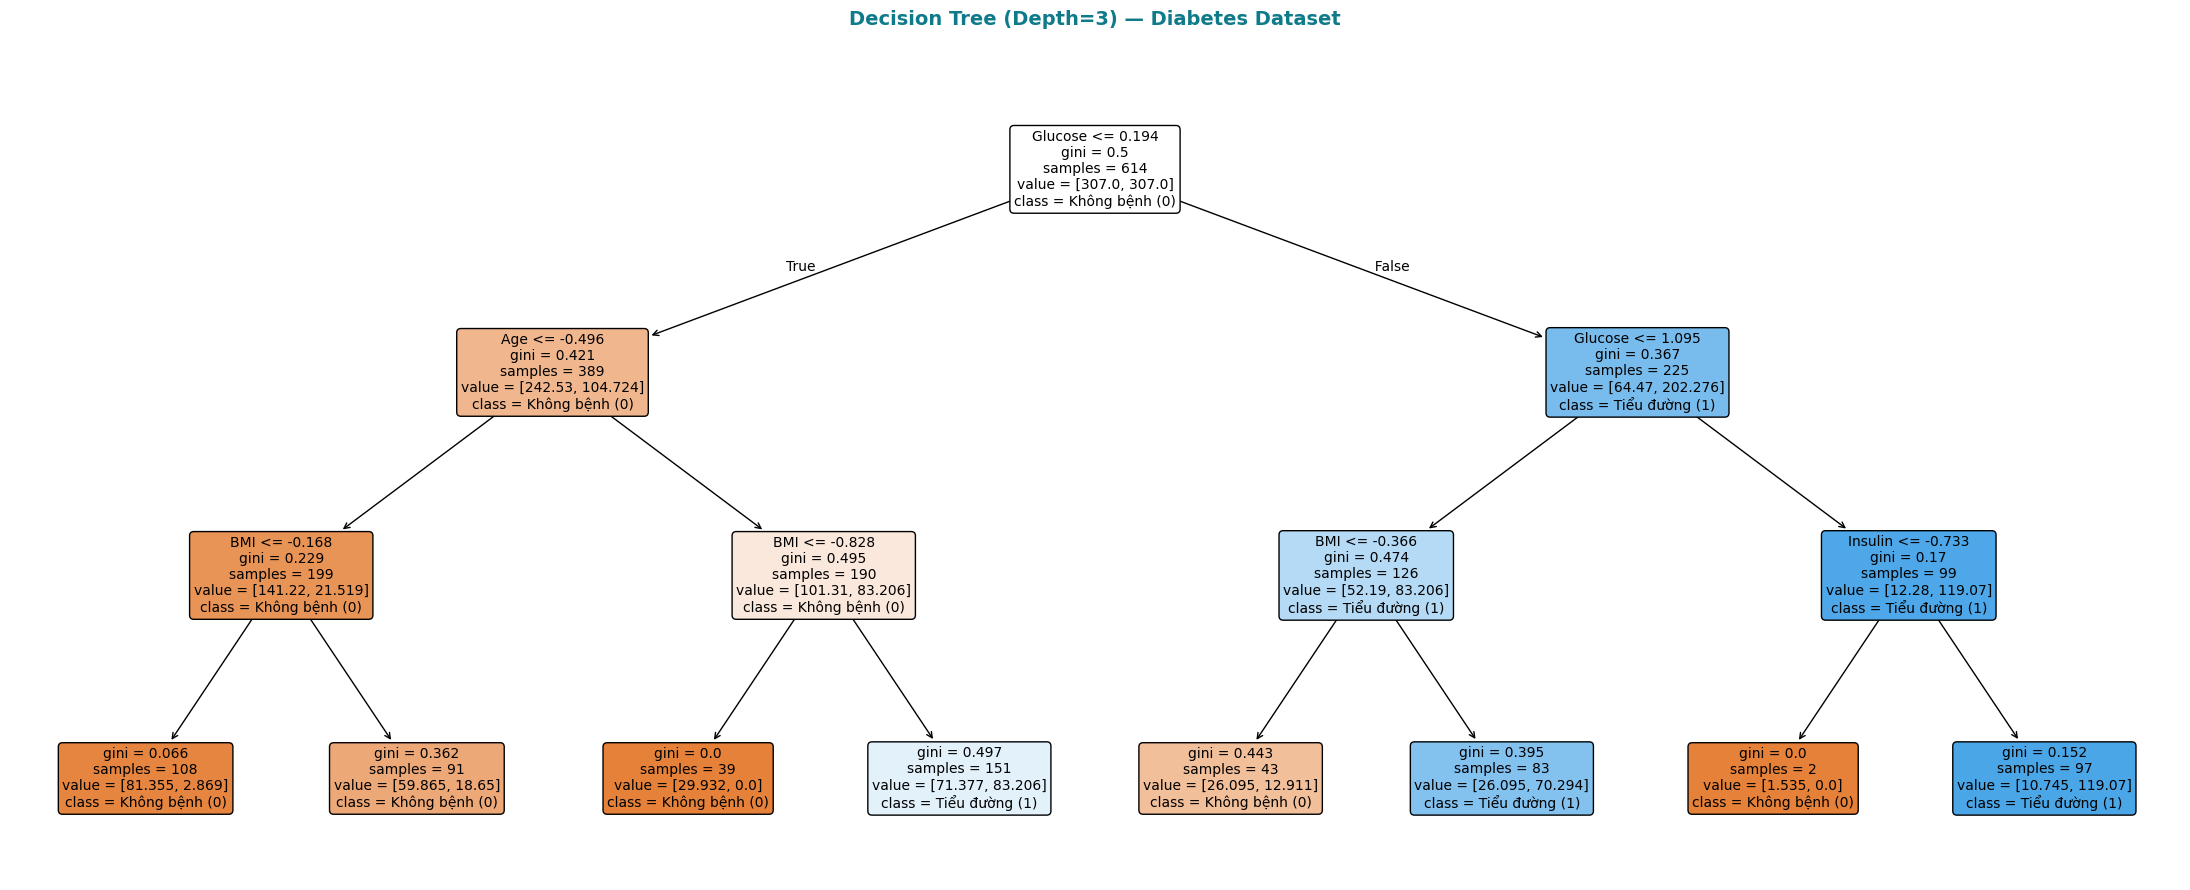


 Cấu trúc cây dạng text (3 tầng đầu):
|--- Glucose <= 0.19
|   |--- Age <= -0.50
|   |   |--- BMI <= -0.17
|   |   |   |--- class: 0
|   |   |--- BMI >  -0.17
|   |   |   |--- class: 0
|   |--- Age >  -0.50
|   |   |--- BMI <= -0.83
|   |   |   |--- class: 0
|   |   |--- BMI >  -0.83
|   |   |   |--- class: 1
|--- Glucose >  0.19
|   |--- Glucose <= 1.10
|   |   |--- BMI <= -0.37
|   |   |   |--- class: 0
|   |   |--- BMI >  -0.37
|   |   |   |--- class: 1
|   |--- Glucose >  1.10
|   |   |--- Insulin <= -0.73
|   |   |   |--- class: 0
|   |   |--- Insulin >  -0.73
|   |   |   |--- class: 1



In [ ]:
# ── Vẽ cây Decision Tree (depth=3) ──────────────────────────
# Dùng best_model từ GridSearch của Phú để vẽ cây tối ưu
dt_model      = best_model.named_steps["clf"]
feature_names = list(X.columns)

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=feature_names,
    class_names=["Không bệnh (0)", "Tiểu đường (1)"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
ax.set_title(
    "Decision Tree (Depth=3) — Diabetes Dataset\n",
    fontsize=14, fontweight="bold", color="#0E7A8A", pad=15
)
plt.tight_layout()
plt.show()

print("\n Cấu trúc cây dạng text (3 tầng đầu):")
print(export_text(dt_model, feature_names=feature_names, max_depth=3))

In [ ]:
# ── Feature Importance ───────────────────────────────────────
importances = dt_model.feature_importances_

fi_df = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(" Feature Importance:")
print("-" * 50)
for i, row in fi_df.iterrows():
    bar = "█" * int(row["Importance"] * 50)
    print(f"  {i+1}. {row['Feature']:<30} {row['Importance']*100:5.1f}%  {bar}")

 Feature Importance:
--------------------------------------------------
  1. Glucose                         61.3%  ██████████████████████████████
  2. BMI                             22.0%  ███████████
  3. Age                             14.5%  ███████
  4. Insulin                          2.1%  █
  5. SkinThickness                    0.0%  
  6. BloodPressure                    0.0%  
  7. Pregnancies                      0.0%  
  8. DiabetesPedigreeFunction         0.0%  


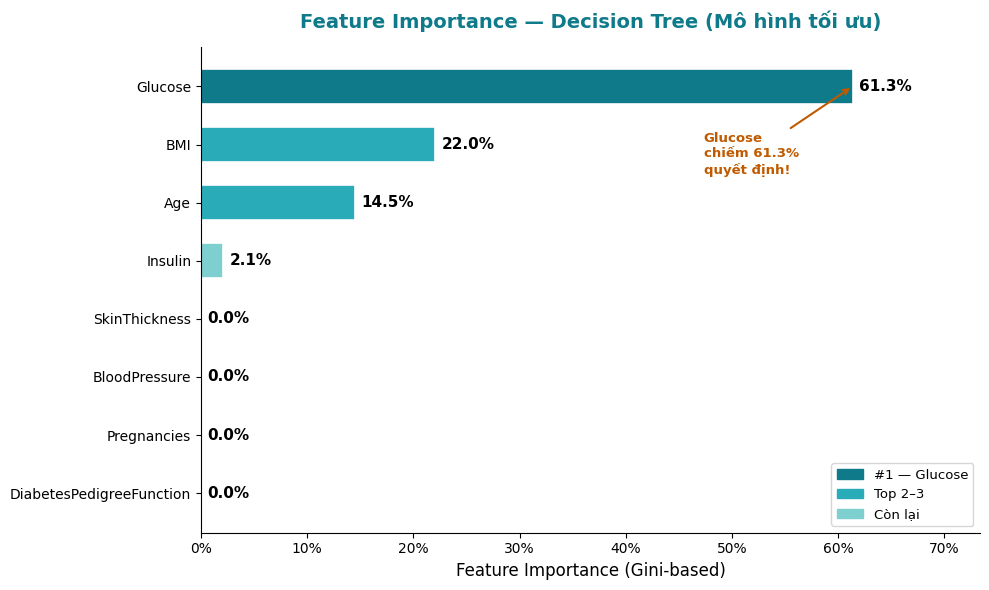

In [ ]:
# ── Biểu đồ Feature Importance ──────────────────────────────
import matplotlib.patches as mpatches

colors_bar = ["#0E7A8A" if i == 0 else "#2AABB8" if i <= 2 else "#7ECFCF"
              for i in range(len(fi_df))]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1],
               color=colors_bar[::-1], height=0.6,
               edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, fi_df["Importance"][::-1]):
    ax.text(bar.get_width() + 0.006, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Feature Importance (Gini-based)", fontsize=12)
ax.set_title("Feature Importance — Decision Tree (Mô hình tối ưu)",
             fontsize=14, fontweight="bold", color="#0E7A8A", pad=14)
ax.set_xlim(0, fi_df["Importance"].max() + 0.12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

top = fi_df.iloc[0]
ax.annotate(
    f"{top['Feature']}\nchiếm {top['Importance']*100:.1f}%\nquyết định!",
    xy=(top["Importance"], len(fi_df) - 1),
    xytext=(top["Importance"] - 0.14, len(fi_df) - 2.5),
    fontsize=9.5, color="#C05A00", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#C05A00", lw=1.5)
)

patches = [
    mpatches.Patch(color="#0E7A8A", label=f"#1 — {fi_df.iloc[0]['Feature']}"),
    mpatches.Patch(color="#2AABB8", label="Top 2–3"),
    mpatches.Patch(color="#7ECFCF", label="Còn lại"),
]
ax.legend(handles=patches, loc="lower right", fontsize=9.5)
plt.tight_layout()
plt.show()

In [ ]:
# ── Giải thích y khoa: Glucose, BMI, Age ────────────────────
print(" GIẢI THÍCH Y KHOA — TOP 3 FEATURES:")
print()

top3 = [
    (
        "Glucose",
        fi_df[fi_df['Feature']=='Glucose']['Importance'].values[0],
        "Đường huyết lúc đói — tiêu chí chẩn đoán tiểu đường trực tiếp.",
        "WHO: Glucose ≥ 126 mg/dL → xác nhận mắc tiểu đường.",
        "→ Feature quan trọng nhất, là node gốc của cây."
    ),
    (
        "BMI",
        fi_df[fi_df['Feature']=='BMI']['Importance'].values[0],
        "Chỉ số khối cơ thể — đo mức độ béo phì.",
        "BMI cao → mô mỡ nhiều → giảm nhạy cảm insulin → tăng nguy cơ ĐTĐ type 2.",
        "→ BMI ≥ 30 (béo phì) làm tăng nguy cơ gấp 3 lần."
    ),
    (
        "Age",
        fi_df[fi_df['Feature']=='Age']['Importance'].values[0],
        "Tuổi tác — nguy cơ tăng dần theo thời gian.",
        "Sau 45 tuổi: tụy suy giảm chức năng, tế bào beta tiết insulin kém hơn.",
        "→ Nguy cơ tiểu đường type 2 tăng rõ rệt sau 45 tuổi."
    ),
]

for feat, imp, mo_ta, chi_tiet, nhan_xet in top3:
    print(f"  {'='*55}")
    print(f"  🔹 {feat} — chiếm {imp*100:.1f}% quyết định")
    print(f"     {mo_ta}")
    print(f"     {chi_tiet}")
    print(f"     {nhan_xet}")
    print()

print(f"  {'='*55}")
print("   Kết luận: Mô hình học máy đồng thuận với y học.")
print("     Glucose → BMI → Age là 3 yếu tố nguy cơ hàng đầu")
print("     được cả bác sĩ lẫn cây quyết định xác nhận.")

 GIẢI THÍCH Y KHOA — TOP 3 FEATURES:

  🔹 Glucose — chiếm 61.3% quyết định
     Đường huyết lúc đói — tiêu chí chẩn đoán tiểu đường trực tiếp.
     WHO: Glucose ≥ 126 mg/dL → xác nhận mắc tiểu đường.
     → Feature quan trọng nhất, là node gốc của cây.

  🔹 BMI — chiếm 22.0% quyết định
     Chỉ số khối cơ thể — đo mức độ béo phì.
     BMI cao → mô mỡ nhiều → giảm nhạy cảm insulin → tăng nguy cơ ĐTĐ type 2.
     → BMI ≥ 30 (béo phì) làm tăng nguy cơ gấp 3 lần.

  🔹 Age — chiếm 14.5% quyết định
     Tuổi tác — nguy cơ tăng dần theo thời gian.
     Sau 45 tuổi: tụy suy giảm chức năng, tế bào beta tiết insulin kém hơn.
     → Nguy cơ tiểu đường type 2 tăng rõ rệt sau 45 tuổi.

   Kết luận: Mô hình học máy đồng thuận với y học.
     Glucose → BMI → Age là 3 yếu tố nguy cơ hàng đầu
     được cả bác sĩ lẫn cây quyết định xác nhận.
